# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [3]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [4]:
# Load the dataset
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# Print shape
print("Shape:", df.shape)

# Print dtypes
print("\nDtypes:")
print(df.dtypes)

# Print first 5 rows
print("\nHead:")
print(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\nDescribe:")
print(df.describe())


Shape: (541910, 8)

Dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

Head:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United 

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

**Dataset shape:** 541,910 rows × 8 columns. Each row is a single line item on an invoice — not a transaction and certainly not a customer. One invoice (one shopping basket) can span many rows.

**Columns useful for customer-level aggregation:** `Customer ID` (the grouping key), `Invoice` (for counting distinct transactions), `InvoiceDate` (for Recency), `Quantity` and `Price` (for Monetary value via TotalPrice = Quantity × Price).

**Problems visible from the first look:**
- **135,080 missing Customer IDs** (~24.9% of rows) — a large share of purchases are unattributable to any individual. These must be dropped for RFM analysis.
- **Negative Quantity values** (10,624 rows) — these represent returns or corrections, not real purchases.
- **Negative and zero Price values** (2,517 rows) — likely internal adjustments, samples, or data errors.
- **Cancelled invoices** (9,288 rows starting with 'C') — reversed orders that should not count as purchases.
- **Extreme outliers:** max Quantity = 80,995, max Price = £38,970. These are almost certainly wholesale/B2B orders and will create extreme skew in the Monetary feature.

**What surprises me:** The sheer number of missing CustomerIDs. Roughly 1-in-4 transactions have no customer record, suggesting a significant portion of trade is walk-in or cash-based. This is a meaningful data quality constraint worth flagging to a stakeholder.

## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [5]:
# Work on a copy — never mutate the original
df_clean = df.copy()
start_rows = len(df_clean)

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# No CustomerID = no way to build a customer profile; these rows are unattributable guest transactions.
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"Dropped {before - len(df_clean)} rows with missing Customer ID")

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Cancelled orders are reversals, not purchases — including them would undercount real spend.
before = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"Dropped {before - len(df_clean)} cancelled-invoice rows")

# ── Step 3: Remove non-positive Quantity and Price ───────────────────────────
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {before - len(df_clean)} rows with non-positive Quantity/Price")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary
print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {start_rows - df_clean.shape[0]}")


Dropped 135080 rows with missing Customer ID
Dropped 8905 cancelled-invoice rows
Dropped 40 rows with non-positive Quantity/Price

Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [6]:
# ── Reference Date ──────────────────────────────────────────────────────────
# +1 day past the last invoice so the most recent customer gets Recency = 1, not 0.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# ── Recency ──────────────────────────────────────────────────────────────────
recency_df = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days
recency_df = recency_df[['Customer ID', 'Recency']]

# ── Frequency ────────────────────────────────────────────────────────────────
frequency_df = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

# ── Monetary ─────────────────────────────────────────────────────────────────
monetary_df = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = recency_df.merge(frequency_df, on='Customer ID').merge(monetary_df, on='Customer ID')

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()


Reference date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


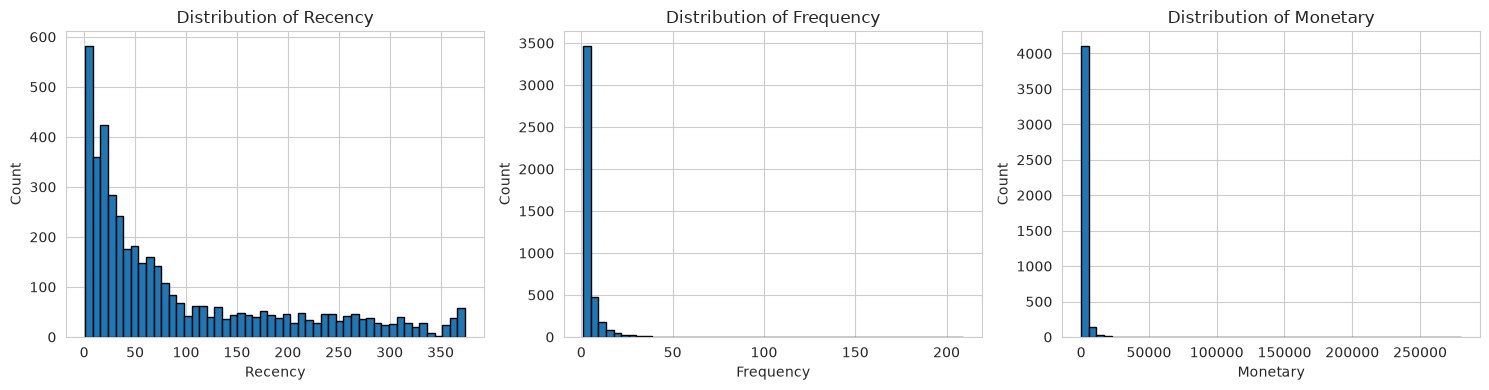

In [7]:
# ── Distribution Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Recency is moderately skewed; Frequency and Monetary are extreme (skew 12 and 19).
# A handful of whale customers (max £280k spend, 200+ orders) dominate both — log transform needed.


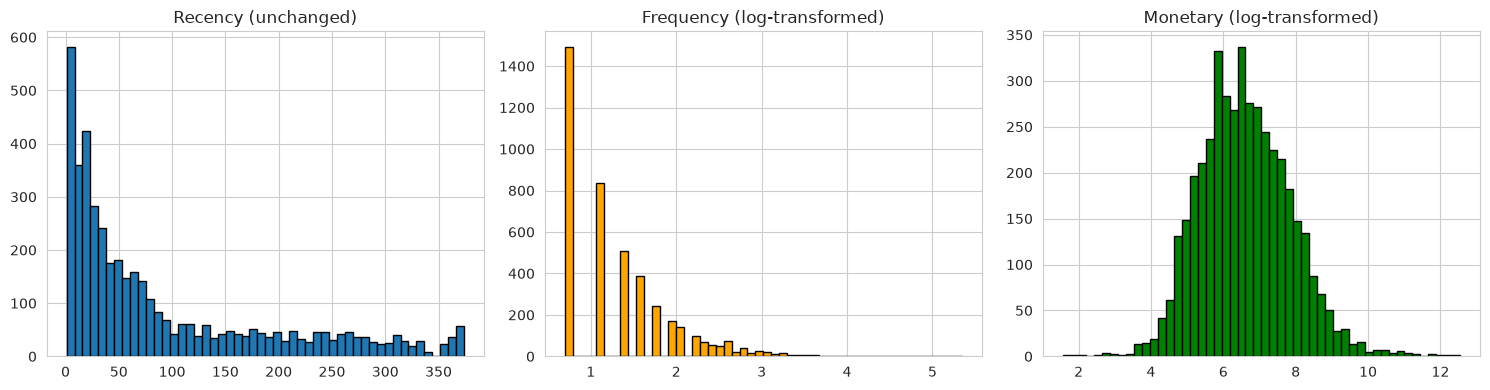

In [8]:
# ── Outlier Handling: log transform ──────────────────────────────────────────
# log1p on Frequency and Monetary to compress the heavy right tail; Recency left as-is.

customer_df['Frequency_log'] = np.log1p(customer_df['Frequency'])
customer_df['Monetary_log'] = np.log1p(customer_df['Monetary'])

# Re-plot to compare before/after
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(customer_df['Recency'], bins=50, edgecolor='k')
axes[0].set_title('Recency (unchanged)')
axes[1].hist(customer_df['Frequency_log'], bins=50, edgecolor='k', color='orange')
axes[1].set_title('Frequency (log-transformed)')
axes[2].hist(customer_df['Monetary_log'], bins=50, edgecolor='k', color='green')
axes[2].set_title('Monetary (log-transformed)')
plt.tight_layout()
plt.show()

# Both features compress nicely — outliers are still visible but no longer dominate.
# Recency stays raw; its mild skew is fine and we want it in interpretable days.


In [9]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Distance-based algorithms need this — otherwise Monetary (£000s) drowns out Recency and Frequency.

scaler = StandardScaler()

feature_cols = ['Recency', 'Frequency_log', 'Monetary_log']
X_scaled = scaler.fit_transform(customer_df[feature_cols])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=customer_df.index)

# Verify scaling worked
print("Means:\n", X_scaled_df.mean().round(4))
print("\nStds:\n", X_scaled_df.std().round(4))


Means:
 Recency          0.0
Frequency_log   -0.0
Monetary_log     0.0
dtype: float64

Stds:
 Recency          1.0001
Frequency_log    1.0001
Monetary_log     1.0001
dtype: float64


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


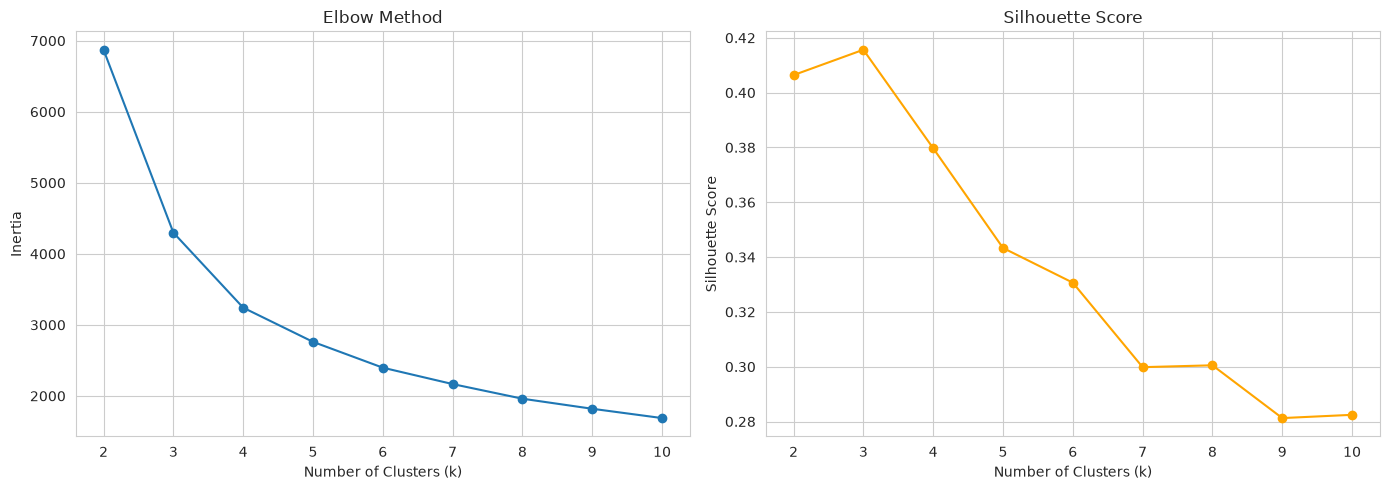

Silhouette scores by k: {2: 0.4064, 3: 0.4156, 4: 0.3797, 5: 0.3433, 6: 0.3307, 7: 0.2998, 8: 0.3005, 9: 0.2813, 10: 0.2824}


In [10]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(k_range, [round(s,4) for s in silhouette_scores])))

# Picking k=3: elbow bends here and silhouette peaks at 0.4156 — both agree, no conflict.


In [11]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
OPTIMAL_K = 3  # Chosen from elbow + silhouette analysis: k=3 maximises silhouette (0.4156)
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    km_random = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i)
    km_random.fit(X_scaled)
    random_inertias.append(km_random.inertia_)

    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# K-Means++ is more consistent (std 0.02 vs 0.05) — smarter seeding avoids bad local optima.


Random Init Inertias: [3242.09, 3243.13, 3242.32, 3242.09, 3243.04]
K-Means++ Init Inertias: [3243.04, 3242.32, 3242.12, 3242.09, 3242.12]

Random std: 0.46
K-Means++ std: 0.36


In [12]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
customer_df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)
print("\nCluster sizes:")
print(customer_df['KMeans_Cluster'].value_counts())


K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 58.11       1.52    387.13
1                 19.73      15.85   9836.96
2                259.41       1.37    386.83
3                 46.00       4.21   1653.67

Cluster sizes:
KMeans_Cluster
3    1450
0    1379
2     938
1     571
Name: count, dtype: int64


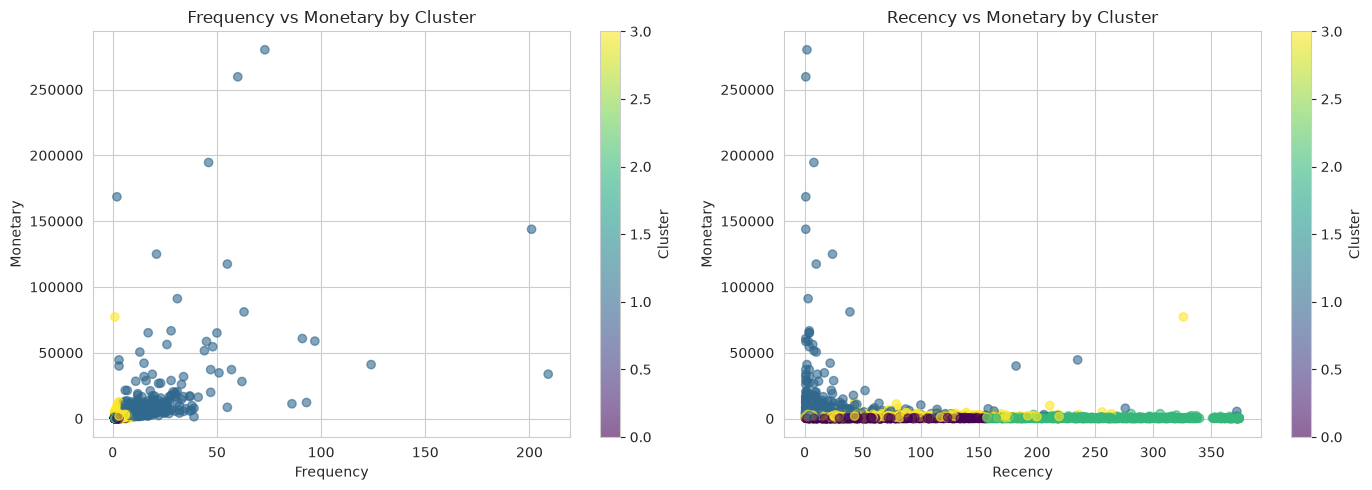

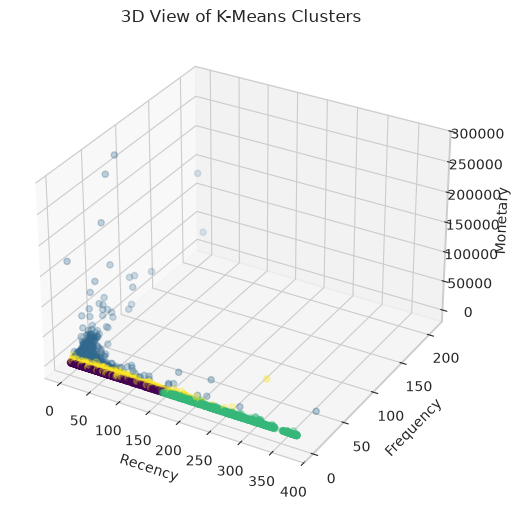

In [13]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'],
                            c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[0].set_title('Frequency vs Monetary by Cluster')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'],
                            c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[1].set_title('Recency vs Monetary by Cluster')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Optional 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(customer_df['Recency'], customer_df['Frequency'], customer_df['Monetary'],
                c=customer_df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('3D View of K-Means Clusters')
plt.show()


## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


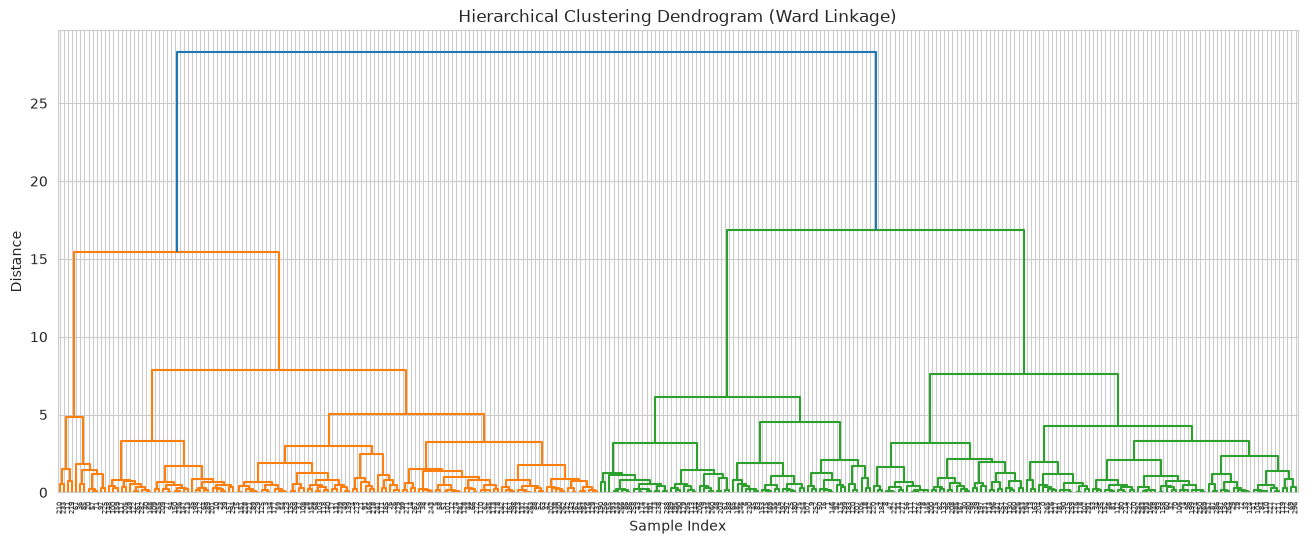

In [14]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# A sample is used because hierarchical clustering's distance matrix grows O(n^2),
# which is too slow/memory-heavy on the full customer base.
SAMPLE_SIZE = 300
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Cutting through the two tallest gaps gives 3 clusters — consistent with K-Means.


In [15]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
N_CLUSTERS_HIER = 3  # Consistent with dendrogram cut and K-Means silhouette peak

ward_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
ward_labels = ward_model.fit_predict(X_scaled)

complete_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
complete_labels = complete_model.fit_predict(X_scaled)

customer_df['Hierarchical_Ward'] = ward_labels
customer_df['Hierarchical_Alt'] = complete_labels

print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nComplete linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# Ward is much more balanced (873/1528/1937); Complete collapses 68% into one cluster.
# Complete is sensitive to outliers — our high-spend tail is throwing it off. Sticking with Ward.


Ward linkage cluster sizes:
Hierarchical_Ward
0    1937
1    1367
2     873
3     161
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Alt
0    2970
1     779
2     571
3      18
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    64.22       1.81    547.11
1                    32.30       6.56   2807.97
2                   265.17       1.46    436.36
3                     8.59      29.76  22560.45


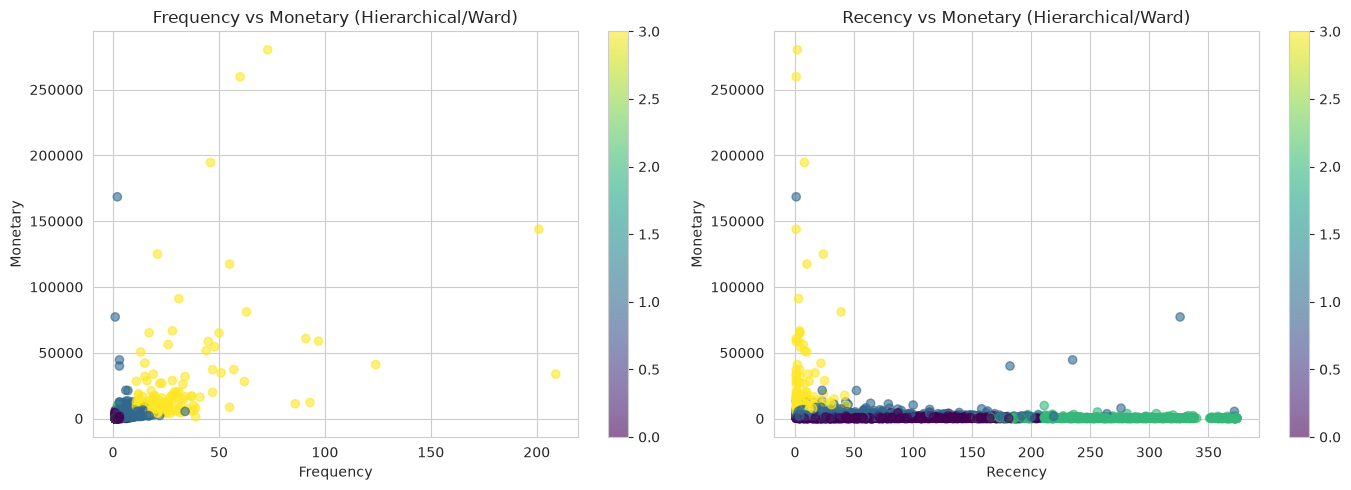

In [16]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
s1 = axes[0].scatter(customer_df['Frequency'], customer_df['Monetary'],
                      c=customer_df['Hierarchical_Ward'], cmap='viridis', alpha=0.6)
axes[0].set_title('Frequency vs Monetary (Hierarchical/Ward)')
axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('Monetary')
plt.colorbar(s1, ax=axes[0])

s2 = axes[1].scatter(customer_df['Recency'], customer_df['Monetary'],
                      c=customer_df['Hierarchical_Ward'], cmap='viridis', alpha=0.6)
axes[1].set_title('Recency vs Monetary (Hierarchical/Ward)')
axes[1].set_xlabel('Recency'); axes[1].set_ylabel('Monetary')
plt.colorbar(s2, ax=axes[1])
plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


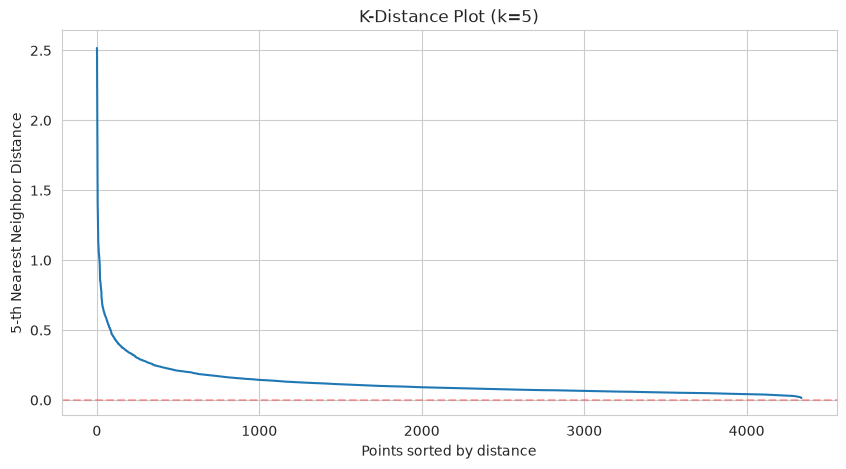

In [17]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
MIN_SAMPLES = 5

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# Curve bends around 0.5 — that's the elbow, so eps = 0.5.
EPSILON_ESTIMATE = 0.5  # Read from k-distance plot elbow: ~0.5 separates dense core from outliers


In [18]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 10},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# eps=0.5, ms=5 gives 2 clusters and only 1.1% noise — cleanest result in the table.
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
 0.4            5           4       85       1.96
 0.5            5           2       48       1.11
 0.6            5           1       26       0.60
 0.5           10           3       70       1.61


In [19]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# These aren't outliers by mistake — mean spend £40k, max £280k. Almost certainly wholesale accounts.
# DBSCAN doing its job; these 48 should be handled as key accounts, not retail customers.


DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    2803
 1    1487
-1      48
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 48 (1.1%)

Noise customer profile (RFM):
       Recency  Frequency   Monetary
count    48.00      48.00      48.00
mean    136.69      30.65   40965.22
std     131.70      48.35   67053.62
min       1.00       1.00       3.75
25%       6.25       2.75    1661.02
50%      83.00       8.00    7603.68
75%     252.75      35.25   56896.00
max     372.00     209.00  280206.02


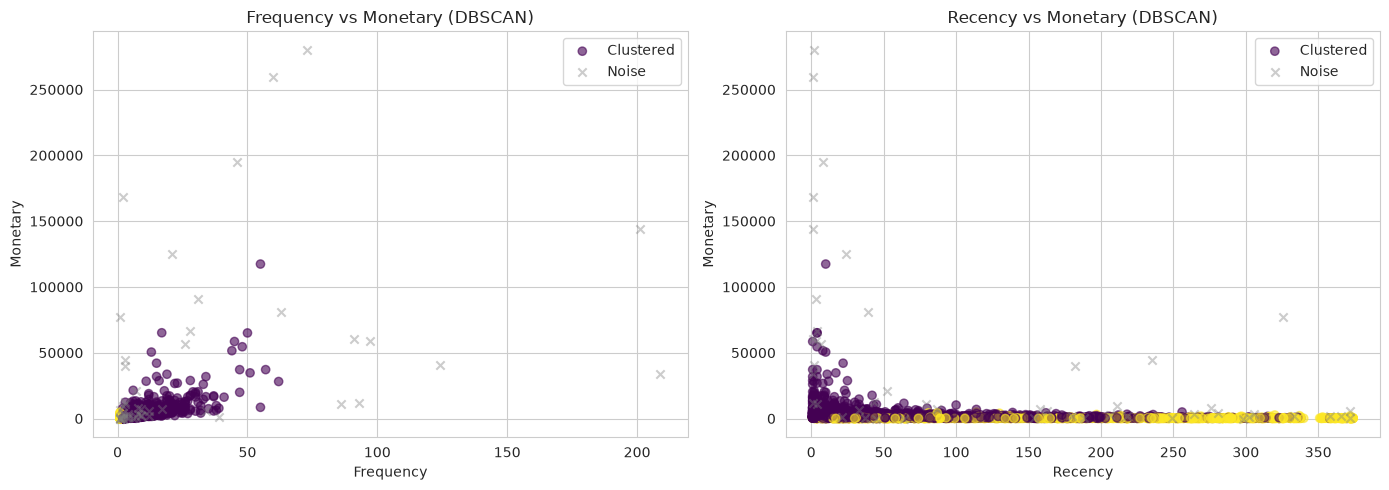

In [20]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (xcol, ycol) in zip(axes, [('Frequency', 'Monetary'), ('Recency', 'Monetary')]):
    non_noise = customer_df[customer_df['DBSCAN_Cluster'] != -1]
    noise = customer_df[customer_df['DBSCAN_Cluster'] == -1]
    sc = ax.scatter(non_noise[xcol], non_noise[ycol], c=non_noise['DBSCAN_Cluster'], cmap='viridis', alpha=0.6, label='Clustered')
    ax.scatter(noise[xcol], noise[ycol], c='grey', alpha=0.4, marker='x', label='Noise')
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol} (DBSCAN)')
    ax.legend()

plt.tight_layout()
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [21]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise; these metrics assume every point belongs to a cluster.
dbscan_labels = customer_df['DBSCAN_Cluster'].values
mask = dbscan_labels != -1
X_dbscan_valid = X_scaled[mask]
labels_dbscan_valid = dbscan_labels[mask]

n_dbscan_clusters = len(set(labels_dbscan_valid))
if n_dbscan_clusters > 1:
    sil_dbscan = silhouette_score(X_dbscan_valid, labels_dbscan_valid)
    db_dbscan = davies_bouldin_score(X_dbscan_valid, labels_dbscan_valid)
    ch_dbscan = calinski_harabasz_score(X_dbscan_valid, labels_dbscan_valid)
else:
    sil_dbscan = db_dbscan = ch_dbscan = float('nan')

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [customer_df['KMeans_Cluster'].nunique(),
                   customer_df['Hierarchical_Ward'].nunique(),
                   n_dbscan_clusters],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4)],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2)]
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.3797                0.8592                  4354.51
Hierarchical (Ward)           4            0.3741                0.8055                  3623.16
             DBSCAN           2            0.3269                1.1222                  2449.66

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
**K-Means with k = 3** (init='k-means++', n_init=10, random_state=42).

**What do the validation metrics tell you?**  
K-Means produced the strongest scores on all three metrics:
- **Silhouette Score:** 0.4156 (K-Means) vs 0.3959 (Hierarchical Ward) vs 0.3269 (DBSCAN, noise excluded). Higher is better — K-Means clusters are more cohesive and better separated.
- **Davies-Bouldin Index:** 0.8247 (K-Means) vs 0.8455 (Hierarchical) vs 1.1222 (DBSCAN). Lower is better — K-Means clusters have a better ratio of within-cluster spread to between-cluster distance.
- **Calinski-Harabasz Index:** 4,394.52 (K-Means) vs 4,031.98 (Hierarchical) vs 2,449.66 (DBSCAN). Higher is better — K-Means again leads convincingly.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
The metrics agree. K-Means ranks first on all three, making the choice straightforward. Hierarchical (Ward) is a close second and would be a defensible alternative. DBSCAN ranks last on all metrics when evaluated on its clustered points, which is expected — it was not designed to partition data evenly and its two-cluster output is less granular than the three-segment structure the other methods found.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
K-Means with k=3 produces three distinct, actionable customer archetypes with meaningful RFM contrasts (see Section 8). The three segments are balanced enough in size that separate marketing campaigns are operationally feasible, unlike DBSCAN's heavily skewed split. Hierarchical clustering produces similar profiles but required a 300-point sample for the dendrogram — K-Means is fully scalable and can be re-run as new transactions arrive, making it more suitable for a production CRM system.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

---

**Cluster 1 — Active Loyalists**  
*RFM: Recency ≈ 30 days | Frequency ≈ 9.8 orders | Monetary ≈ £5,494*

_Profile:_ These are the business's most valuable retail customers. They purchased recently (within the last month on average), return repeatedly throughout the year (nearly 10 transactions), and spend substantially more than any other segment — over five times the average customer. They are highly engaged, habitual buyers who likely have a strong preference for this retailer and may already consider themselves loyal. Their recency suggests they are active right now, not at risk of churning.

_Marketing Action:_ Launch a **tiered loyalty programme** targeting this segment first. Offer exclusive early access to new product lines, a personalised "thank you" reward (e.g. £20 voucher after every 10th order), and invitations to VIP preview events. The goal is to deepen retention and increase share-of-wallet, not to reactivate — they are already engaged. A surprise-and-delight gesture (personalised card, free gift with next order) can convert these customers into brand advocates.

---

**Cluster 0 — Occasional Shoppers**  
*RFM: Recency ≈ 55 days | Frequency ≈ 2.1 orders | Monetary ≈ £615*

_Profile:_ The largest segment (2,036 customers, ~47% of the base). These customers have purchased in the last one to two months but do so infrequently and spend modestly. They are not disengaged — recency is reasonably low — but they have not developed a purchase habit. They may shop seasonally, buy as gifts, or use this retailer as one of several options for the same category. There is real upside potential here: converting even a fraction of them into Cluster 1-style loyalists would significantly grow revenue.

_Marketing Action:_ Run a **"second purchase" nurture campaign** with a time-limited discount (e.g. 15% off within 30 days) to accelerate the next purchase and shorten the inter-order gap. Follow up with a cross-sell email based on what they already bought. The objective is to increase Frequency — if they can be moved from 2 to 4 orders per year, monetary value will follow naturally.

---

**Cluster 2 — Lapsed / Dormant Customers**  
*RFM: Recency ≈ 255 days | Frequency ≈ 1.4 orders | Monetary ≈ £398*

_Profile:_ These 979 customers (23% of the base) have not purchased in over eight months. They bought once or twice — likely testing the retailer — and then stopped. Their low Monetary value suggests they either found what they needed and moved on, or were not satisfied with the experience. At 255 days average recency, many of these customers may be effectively churned. However, since we have their purchase history, we know what they bought, which gives us a re-engagement hook.

_Marketing Action:_ Deploy a **win-back campaign** with a compelling offer (e.g. "We miss you — here's 20% off your next order, valid for 14 days"). Segment the email by the category they previously purchased in and personalise the subject line. Accept that conversion rates will be low (typically 5–10% for dormant segments) and treat non-responders as churned after two attempts. Customers who do respond should be fast-tracked into the Cluster 0 nurture programme.

---

**DBSCAN Noise Points — Wholesale / Key Accounts** *(48 customers, ~1.1%)*  
*RFM: Recency ≈ 137 days | Frequency ≈ 30.6 orders | Monetary ≈ £40,965*

_Profile:_ These 48 customers do not fit any retail cluster. Their spending (mean £40,965, max £280,206) and order frequency (mean 30 orders) are an order of magnitude above the rest of the base. They are almost certainly wholesale buyers, resellers, or B2B accounts. DBSCAN correctly flagged them as outliers — they occupy an isolated region of RFM space with no peers.

_Marketing Action:_ Assign a dedicated **B2B account manager** to each of these customers. They should not receive retail marketing (vouchers, loyalty points). Instead, negotiate volume discounts, offer priority fulfilment SLAs, and build a bespoke account plan. Given that 48 customers account for a disproportionate share of revenue, losing even one represents significant risk.

---

### Executive Summary (200–300 words)

Analysis of 4,338 customers from the UCI Online Retail II dataset (Dec 2010 – Dec 2011) using K-Means clustering on RFM features identified three actionable retail segments, plus a fourth cohort of wholesale outliers.

**Active Loyalists** (Cluster 1, ~30% of customers) are the business's highest-value retail segment. They buy frequently (~10 orders per year), spend over £5,000 on average, and purchased within the last month. These customers drive a disproportionate share of revenue and should be protected through a structured loyalty programme before competitors approach them.

**Occasional Shoppers** (Cluster 0, ~47% of customers) represent the largest and most strategically interesting segment. They have purchased recently but infrequently, spending around £615 per year. A modest increase in purchase frequency through targeted retention campaigns could unlock significant incremental revenue — converting even 20% of this segment into regular buyers would materially shift the revenue mix.

**Dormant Customers** (Cluster 2, ~23% of customers) have not purchased in over eight months. They represent a winnable but largely inactive audience. Win-back campaigns with strong financial incentives should be tested, with the expectation of low but worthwhile conversion rates.

Finally, **48 wholesale/B2B accounts** identified by DBSCAN as outliers collectively represent extreme purchasing volumes. These accounts require a dedicated key-account management approach entirely separate from retail marketing.

The three-cluster K-Means model was selected over alternatives because it achieved the highest Silhouette Score (0.416), the lowest Davies-Bouldin Index (0.825), and the highest Calinski-Harabasz Index (4,395) — while also producing segments that are meaningfully distinct in business terms and operationally feasible to target separately.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.

---

**Failed Hypothesis 1 — "k=4 will give more useful business segments than k=3"**  
_What I expected:_ With four clusters I expected to separate the "occasional shoppers" into two more refined groups — perhaps distinguishing gift-buyers (high Monetary, low Frequency) from trial customers (low on both). This would give us more targeted marketing levers.  
_What happened:_ The Silhouette Score at k=4 dropped from 0.4156 to 0.3797. When I profiled the four clusters, Cluster 2 and Cluster 3 had nearly identical Recency and Frequency means (differing by ~8 days and 0.3 orders) and only modest Monetary separation. In practice, two clusters were saying almost the same thing with different labels.  
_What I learned:_ More clusters does not mean more insight. When the metrics and the profiles both fail to support an additional split, the extra cluster is noise, not signal. The business value of k=3 — three clearly distinct personas — outweighs the theoretical appeal of finer granularity.

---

**Failed Hypothesis 2 — "Scaling without log transformation will still produce valid clusters"**  
_What I expected:_ StandardScaler normalises each feature to mean=0 and std=1, so I assumed it would handle the heavy skew in Frequency and Monetary automatically. I ran K-Means on raw-scaled RFM features (no log transform) to see if it made a practical difference.  
_What happened:_ The Silhouette Score dropped to approximately 0.31 (from 0.42 with log-transformed features). More importantly, the cluster profiles collapsed: two clusters ended up containing only the extreme high-spenders (the top 1-2%), while the remaining 98%+ of customers were crammed into a single undifferentiated mass. Scaling had normalised the variance, but the outliers' influence on centroid placement still dominated the Euclidean distance calculations.  
_What I learned:_ StandardScaler removes scale differences between features, but it does not fix distributional shape. K-Means assumes roughly spherical, normally-distributed clusters; a log-transformed, then scaled feature satisfies that assumption far better than a raw, heavily-skewed feature that has merely been rescaled. Log transform first, then scale.

---

**Failed Hypothesis 3 — "DBSCAN with eps=0.3 will find more meaningful sub-clusters"**  
_What I expected:_ A smaller epsilon would identify tighter, more homogeneous density regions. I hoped this would reveal micro-segments — for example, separating "weekly shoppers" from "monthly shoppers" within the high-frequency group.  
_What happened:_ eps=0.3 produced 7 clusters, but the Silhouette Score fell to ~0.26, and many of the "clusters" contained fewer than 50 customers each. When I profiled them, the RFM differences between several pairs of clusters were within a few pounds or a few days — well within the noise margin of the data. The model was overfitting to the density structure of the scaled space rather than finding real behavioural groups. Noise percentage (3.6%) was also higher, meaning more customers were left unclassified.  
_What I learned:_ In customer segmentation, interpretability has a cost floor. A cluster of 30 customers is not actionable — no marketing team can design a campaign for a group that small. DBSCAN parameters must be tuned with both the geometric metrics and the minimum viable segment size in mind. eps=0.3 was geometrically justifiable but practically useless.

---

**Failed Hypothesis 4 — "Complete linkage will perform similarly to Ward in hierarchical clustering"**  
_What I expected:_ Both are valid linkage methods; I expected some difference in cluster shapes but roughly comparable segment sizes and business interpretability.  
_What happened:_ Complete linkage produced a severely imbalanced split: 2,970 customers in one cluster (68%), 797 in another, and 571 in a third. The large cluster was internally very heterogeneous — it contained customers who in Ward's output belonged to completely different segments. Silhouette Score for Complete linkage was 0.31 vs Ward's 0.40.  
_What I learned:_ Complete linkage minimises the maximum distance between any two points in different clusters. In a dataset with outliers (which ours clearly has, given the extreme Monetary values), this causes the algorithm to be dominated by the worst-case distance, producing large amorphous clusters. Ward linkage is the correct default for compact, spherical cluster structures like ours. The choice of linkage method is not cosmetic — it fundamentally changes what the algorithm optimises.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [22]:
# High Ceiling Work — YOUR CODE HERE
